In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
mpl.style.use('classic')

import baraffe_tables
from baraffe_tables.table_search import baraffe_table_search

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil

%matplotlib inline

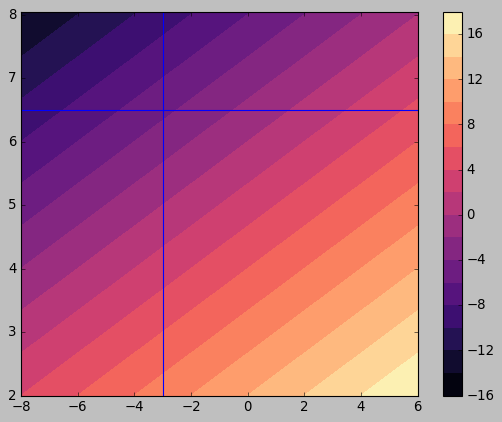

In [8]:
log10T = np.arange(2,8.05,0.05)
log10rho = np.arange(-8.,6.05,0.05)

tt, rr = np.meshgrid(log10T, log10rho)

fig, ax = plt.subplots(1,1,figsize=(8,6))

logR = ax.contourf(rr,tt, rr - 3*tt + 18, cmap = 'magma',levels=20)

plt.colorbar(logR)
ax.axvline(-3.)
ax.axhline(6.5)
plt.show()

In [4]:
kap_data_dir = "/Users/emily/mesa-24.08.1/kap/preprocessor/data/kap_data"

In [17]:
sieb = [f for f in os.listdir(kap_data_dir) if os.path.isfile(os.path.join(kap_data_dir, f)) and "siebenaler" in f]
freed = [f for f in os.listdir(kap_data_dir) if os.path.isfile(os.path.join(kap_data_dir, f)) and "Freedman" in f]

print(len(sieb))
print(len(freed))
sieb_logR = np.array((-8.000, -7.800, -7.600, -7.400, -7.200, -7.000, -6.800, -6.600, -6.400, -6.200, -6.000, -5.800, -5.600, -5.400, -5.200, -5.000, -4.800, -4.600, -4.400, -4.200, -4.000, -3.800, -3.600, -3.400, -3.200, -3.000, -2.800, -2.600, -2.400, -2.200, -2.000, -1.800, -1.600, -1.400, -1.200, -1.000, -0.800, -0.600, -0.400, -0.200,  0.000,  0.200,  0.400,  0.600,  0.800,  1.000,  1.200,  1.400,  1.600,  1.800,  2.000,  2.200,  2.400,  2.600,  2.800,  3.000,  3.200,  3.400,  3.600,  3.800,  4.000,  4.200,  4.400,  4.600,  4.800,  5.000,  5.200,  5.400,  5.600,  5.800,  6.000,  6.200,  6.400,  6.600,  6.800,  7.000,  7.200,  7.400,  7.600,  7.800,  8.000,  8.200,  8.400,  8.600,  8.800,  9.000,  9.200,  9.400,  9.600,  9.800, 10.000, 10.200, 10.400, 10.600, 10.800, 11.000, 11.200, 11.400, 11.600, 11.800, 12.000, 12.200, 12.400))
freed_logR = np.array((-8.000, -7.800, -7.600, -7.400, -7.200, -7.000, -6.800, -6.600, -6.400, -6.200, -6.000, -5.800, -5.600, -5.400, -5.200, -5.000, -4.800, -4.600, -4.400, -4.200, -4.000, -3.800, -3.600, -3.400, -3.200, -3.000, -2.800, -2.600, -2.400, -2.200, -2.000, -1.800, -1.600, -1.400, -1.200, -1.000, -0.800, -0.600, -0.400, -0.200,  0.000,  0.200,  0.400,  0.600,  0.800,  1.000,  1.200,  1.400,  1.600,  1.800,  2.000,  2.200,  2.400,  2.600,  2.800,  3.000,  3.200,  3.400,  3.600,  3.800,  4.000,  4.200,  4.400,  4.600,  4.800,  5.000,  5.200,  5.400,  5.600,  5.800,  6.000,  6.200,  6.400,  6.600,  6.800,  7.000,  7.200,  7.400,  7.600,  7.800,  8.000,  8.200,  8.400,  8.600,  8.800,  9.000))

sieb_logT = np.genfromtxt(kap_data_dir+'/'+sieb[0], skip_header=7)[:,0]
freed_logT = np.genfromtxt(kap_data_dir+'/'+freed[0], skip_header=7)[:,0]
print(freed_logT)

12
7
[1.88  2.    2.04  2.08  2.11  2.15  2.18  2.2   2.23  2.26  2.28  2.3
 2.32  2.34  2.36  2.38  2.4   2.44  2.48  2.6   2.7   2.76  2.81  2.85
 2.9   2.91  2.92  2.93  2.94  2.95  2.96  2.97  2.98  2.99  3.    3.01
 3.02  3.03  3.04  3.05  3.06  3.07  3.08  3.09  3.1   3.11  3.12  3.13
 3.14  3.15  3.16  3.17  3.18  3.19  3.2   3.21  3.22  3.23  3.24  3.25
 3.26  3.27  3.28  3.29  3.3   3.31  3.32  3.33  3.34  3.35  3.36  3.37
 3.38  3.39  3.4   3.41  3.42  3.43  3.44  3.45  3.46  3.47  3.48  3.49
 3.5   3.525 3.55  3.575 3.6   3.625 3.65  3.675 3.7   3.725 3.75  3.775
 3.8   3.825 3.85  3.875 3.9   3.925 3.95  3.975 4.    4.025 4.05  4.075
 4.1   4.125 4.15  4.175 4.2   4.225 4.25  4.275 4.3   4.325 4.35  4.375
 4.4   4.425 4.45  4.475 4.5  ]


In [74]:
def plot_opacities(filename,logTarr,logRarr):

    logTgrid,logRgrid = np.meshgrid(logTarr,logRarr)

    kap = np.genfromtxt(filename,skip_header=7)[:,1:]

    fig, axes = plt.subplots(2,1,figsize=(8,12))

    kaps = axes[0].contourf(logRgrid,logTgrid,kap.T,cmap='magma',levels=50)
    axes[0].set_ylabel('log10T')
    axes[0].set_xlabel('log10R')
    fig.colorbar(kaps,ax=axes[0],label='opacity')


    
    logrhogrid = logRgrid + 3*logTgrid - 18
    
    kaps = axes[1].contourf(logrhogrid,logTgrid,kap.T,cmap='magma',levels=50)
    axes[1].set_ylabel('log10T')
    axes[1].set_xlabel('log10rho')
    axes[1].axvline(0.4)
    fig.colorbar(kaps,ax=axes[1],label='opacity')
    
    plt.show()

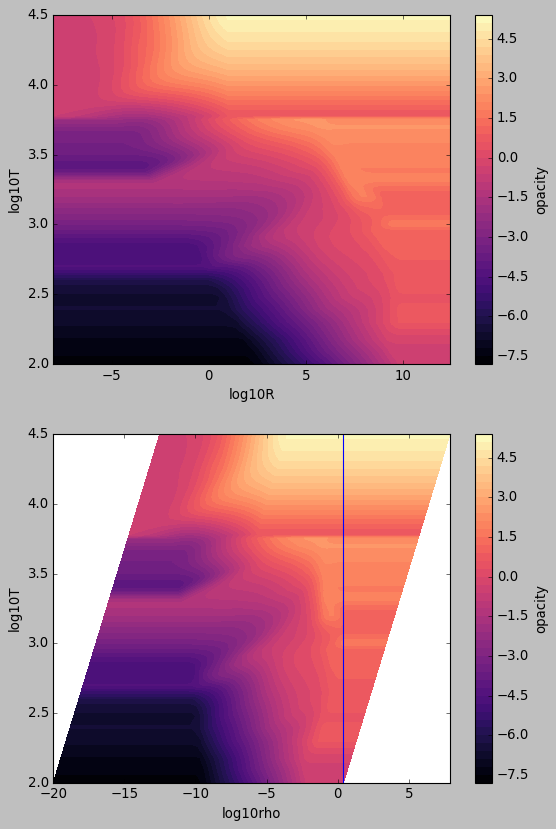

In [75]:
plot_opacities(kap_data_dir+'/'+sieb[0],logTarr=sieb_logT,logRarr=sieb_logR)

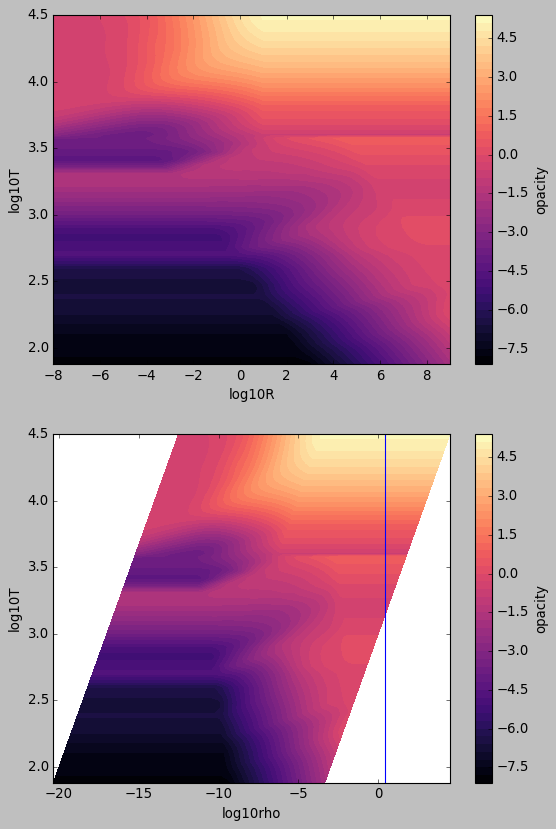

In [76]:
plot_opacities(kap_data_dir+'/'+freed[0],logTarr=freed_logT,logRarr=freed_logR)

In [77]:
test_louis = "/Users/emily/mesa-24.08.1/kap/preprocessor/kap_input_data/siebenaler_cloudfree_rainout/LS26_cf_+0.0_rainout_TRHO.dat"

In [78]:
test = Table.read(test_louis,format='ascii')
print(test)

log10T(K) log10rho(gcm-3) log10P(bar) ...  kappaP6    kappaR7    kappaP7 
--------- --------------- ----------- ... --------- ----------- ---------
      2.0        -11.6254        -6.0 ... 0.0306123 1.41707e-05 0.0212505
      2.0        -11.1784        -6.0 ... 0.0306123 1.41707e-05 0.0212505
      2.0        -10.7313        -6.0 ... 0.0306123 1.41707e-05 0.0212505
      2.0        -10.2843        -6.0 ... 0.0306123 1.41707e-05 0.0212505
      2.0         -9.8372        -6.0 ... 0.0306123 1.41707e-05 0.0212505
      2.0        -9.39015    -5.83294 ... 0.0306123 1.51121e-05 0.0212505
      2.0        -8.94309    -5.38588 ... 0.0306117   1.796e-05 0.0212502
      2.0        -8.49604    -4.93882 ... 0.0305781 2.13714e-05 0.0212274
      2.0        -8.04898    -4.49173 ... 0.0302085 2.53484e-05 0.0209773
      2.0        -7.60192    -4.04453 ... 0.0281119 2.86603e-05  0.019558
      ...             ...         ... ...       ...         ...       ...
  3.77815        -3.57842     1.94865 

In [79]:
T = np.array(test['log10T(K)']).reshape(47,28)
print(T)
rho = np.array(test['log10rho(gcm-3)']).reshape(47,28)
print(rho)
kap = np.array(test['kappaRL']).reshape(47,28)
print(kap)

[[2.      2.      2.      ... 2.      2.      2.     ]
 [2.09691 2.09691 2.09691 ... 2.09691 2.09691 2.09691]
 [2.17609 2.17609 2.17609 ... 2.17609 2.17609 2.17609]
 ...
 [3.69897 3.69897 3.69897 ... 3.69897 3.69897 3.69897]
 [3.74036 3.74036 3.74036 ... 3.74036 3.74036 3.74036]
 [3.77815 3.77815 3.77815 ... 3.77815 3.77815 3.77815]]
[[-1.16254e+01 -1.11784e+01 -1.07313e+01 ... -4.49031e-01 -1.97493e-03
   4.45081e-01]
 [-1.16254e+01 -1.11784e+01 -1.07313e+01 ... -4.49031e-01 -1.97493e-03
   4.45081e-01]
 [-1.16254e+01 -1.11784e+01 -1.07313e+01 ... -4.49031e-01 -1.97493e-03
   4.45081e-01]
 ...
 [-1.16254e+01 -1.11784e+01 -1.07313e+01 ... -4.49031e-01 -1.97493e-03
   4.45081e-01]
 [-1.16254e+01 -1.11784e+01 -1.07313e+01 ... -4.49031e-01 -1.97493e-03
   4.45081e-01]
 [-1.16254e+01 -1.11784e+01 -1.07313e+01 ... -4.49031e-01 -1.97493e-03
   4.45081e-01]]
[[2.11874e-08 2.11874e-08 2.11874e-08 ... 3.69420e-01 3.69420e-01
  3.69420e-01]
 [2.65255e-08 2.65255e-08 2.65255e-08 ... 4.30427e-01 4

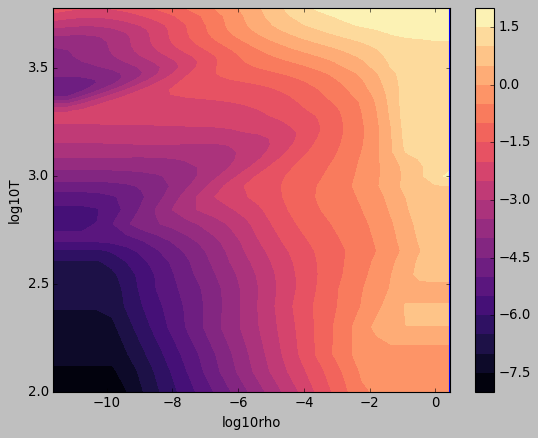

In [81]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

kap_ = ax.contourf(rho,T, np.log10(kap), cmap = 'magma',levels=20)

plt.colorbar(kap_)

ax.set_xlabel('log10rho')
ax.set_ylabel('log10T')
ax.axvline(0.4)
plt.show()